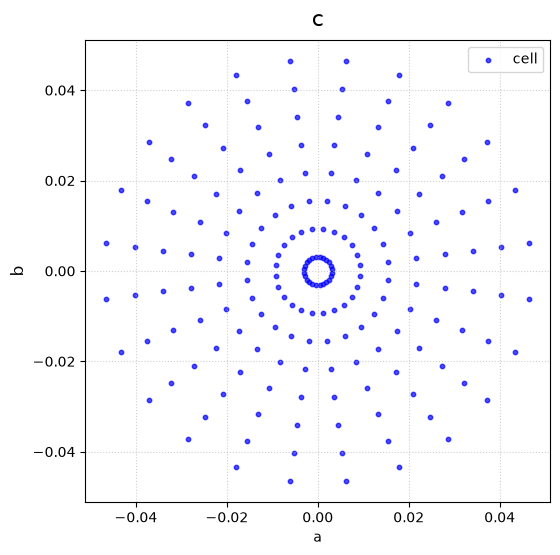

In [12]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("../build/mesh_points.txt")

X = data[:,0]
Y = data[:,1]
Z = data[:,2]

Nr = 8
Ntheta = 24
Nnumber = Nr * Ntheta

Y_slice = Y[:Nnumber]
Z_slice = Z[:Nnumber]

plt.figure(figsize=(6,6))

plt.scatter(Y_slice, Z_slice, color = "blue", s = 10, alpha = 0.7, label = "cell")
plt.grid(True, linestyle=':', alpha=0.6)
plt.title("c", fontsize=16, pad =10)
plt.xlabel("a",fontsize=10)
plt.ylabel("b", fontsize=12)
plt.legend(loc="upper right")
plt.show()

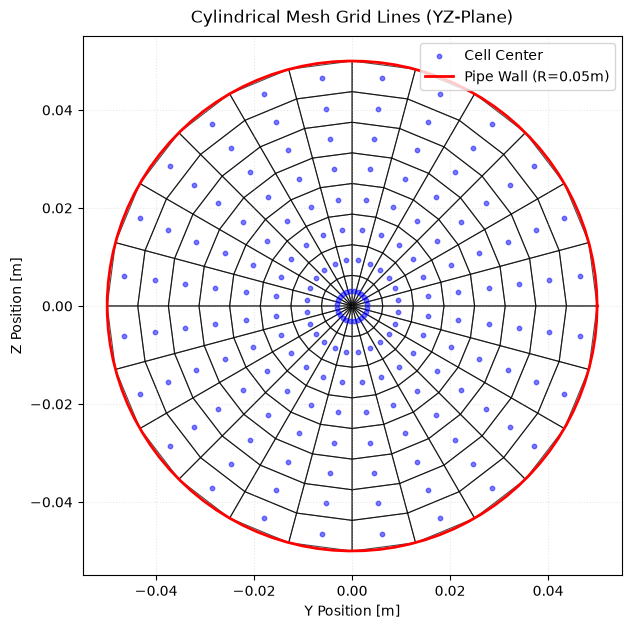

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

Nr = 8
Ntheta = 24
R = 0.05

dr = R / Nr
dtheta = (2.0 * np.pi) / Ntheta

fig, ax = plt.subplots(figsize=(7, 7))

for itheta in range(Ntheta):
    for ir in range(Nr):
        # マスの内側・外側の半径
        r_in = ir * dr
        r_out = (ir + 1) * dr
        
        theta_start = itheta * dtheta
        theta_end = (itheta + 1) * dtheta
        
        p1 = [r_in * np.cos(theta_start), r_in * np.sin(theta_start)]
        p2 = [r_in * np.cos(theta_end),   r_in * np.sin(theta_end)]
        p3 = [r_out * np.cos(theta_end),   r_out * np.sin(theta_end)]
        p4 = [r_out * np.cos(theta_start), r_out * np.sin(theta_start)]
        
        polygon_coords = [p1, p2, p3, p4]
        
        rect = patches.Polygon(
            polygon_coords, 
            closed=True, 
            edgecolor='black',      # 線の色を黒に
            facecolor='none',       # 中身は透明に
            linewidth=0.8,          # 線の太さ
            alpha=0.7
        )
        ax.add_patch(rect)

data = np.loadtxt("../build/mesh_points.txt")
num_cells_in_slice = Nr * Ntheta
Y_slice = data[:num_cells_in_slice, 1]
Z_slice = data[:num_cells_in_slice, 2]
ax.scatter(Y_slice, Z_slice, color='blue', s=10, alpha=0.5, label="Cell Center")

theta_wall = np.linspace(0, 2 * np.pi, 100)
ax.plot(R * np.cos(theta_wall), R * np.sin(theta_wall), 'r-', lw=2, label="Pipe Wall (R=0.05m)")

ax.set_xlim(-R*1.1, R*1.1)
ax.set_ylim(-R*1.1, R*1.1)
ax.set_aspect('equal', adjustable='box')
ax.grid(True, linestyle=':', alpha=0.3)
ax.set_title("Cylindrical Mesh Grid Lines (YZ-Plane)", fontsize=12, pad=10)
ax.set_xlabel("Y Position [m]")
ax.set_ylabel("Z Position [m]")
ax.legend(loc="upper right")

plt.show()